In [4]:
%pip install rasterio -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 48.1 MB/s eta 0:00:00:00:0100:01
Note: you may need to restart the kernel to use updated packages.


In [1]:
path_to_tile_1 = "/kaggle/input/sentinel2-illinois-2023/S2A_MSIL2A_20230520T163841_N0510_R126_T16TCK_20240904T043944.SAFE"

### locating the bands

let's try it on a single tile first

In [3]:
from pathlib import Path

path_to_tile_1 = Path("/kaggle/input/sentinel2-illinois-2023/S2A_MSIL2A_20230520T163841_N0510_R126_T16TCK_20240904T043944.SAFE")

print(f"Searching inside: {path_to_tile_1.name}...\n")

# We use 'rglob' (Recursive Global Search) to find files ending in specific patterns
# We are looking for the 10-meter resolution files
red_band = list(path_to_tile_1.rglob("*_B04_10m.jp2"))
nir_band = list(path_to_tile_1.rglob("*_B08_10m.jp2"))

# Verification
if red_band and nir_band:
    print("SUCCESS: Found the bands!")
    print(f"    Red Path: {red_band[0]}")
    print(f"    NIR Path: {nir_band[0]}")
    
    # Saving these clean paths for Step 2
    red_path = red_band[0]
    nir_path = nir_band[0]
else:
    print("ERROR: Could not find the .jp2 files. Check the folder structure.")

Searching inside: S2A_MSIL2A_20230520T163841_N0510_R126_T16TCK_20240904T043944.SAFE...

SUCCESS: Found the bands!
    Red Path: /kaggle/input/sentinel2-illinois-2023/S2A_MSIL2A_20230520T163841_N0510_R126_T16TCK_20240904T043944.SAFE/S2A_MSIL2A_20230520T163841_N0510_R126_T16TCK_20240904T043944.SAFE/GRANULE/L2A_T16TCK_A041307_20230520T164330/IMG_DATA/R10m/T16TCK_20230520T163841_B04_10m.jp2
    NIR Path: /kaggle/input/sentinel2-illinois-2023/S2A_MSIL2A_20230520T163841_N0510_R126_T16TCK_20240904T043944.SAFE/S2A_MSIL2A_20230520T163841_N0510_R126_T16TCK_20240904T043944.SAFE/GRANULE/L2A_T16TCK_A041307_20230520T164330/IMG_DATA/R10m/T16TCK_20230520T163841_B08_10m.jp2


### opening and reading

In [5]:
import rasterio
from rasterio.windows import Window

print(f"Reading data from: {red_path.name}")

# define a window: col_off, row_off, width, height
# We pick 5000, 5000 to be roughly in the center of the 100km tile
window = Window(5000, 5000, 500, 500)

with rasterio.open(red_path) as red_src, rasterio.open(nir_path) as nir_src:
    # Read band 1 (there is only 1 band in these files)
    red_data = red_src.read(1, window=window)
    nir_data = nir_src.read(1, window=window)

print("Data read successfully.")
print(f"Array Shape: {red_data.shape}")
print(f"Sample Red Value: {red_data[250, 250]}")
print(f"Sample NIR Value: {nir_data[250, 250]}")

Reading data from: T16TCK_20230520T163841_B04_10m.jp2
Data read successfully.
Array Shape: (500, 500)
Sample Red Value: 2604
Sample NIR Value: 3674


The Near-Infrared is higher than Red, which means there is some vegetation, but the values are close. This makes sense for May 20th—the corn is likely just emerging, so the satellite sees mostly soil mixed with tiny plants.

Raw numbers like 2604 are hard to compare because they change based on how bright the sun is. We need a Ratio that cancels out the sun brightness and just tells us "How green is this?"

That ratio is NDVI (Normalized Difference Vegetation Index).

In [6]:
import numpy as np

# 1. Convert to float to allow decimal division
# (Raw satellite data is usually uint16 integers)
red_float = red_data.astype('float32')
nir_float = nir_data.astype('float32')

# 2. Calculate NDVI
# We add 1e-8 (0.00000001) to the denominator to prevent "Divide by Zero" errors
ndvi = (nir_float - red_float) / (nir_float + red_float + 1e-8)

print("NDVI Calculated.")
print(f"Min Value: {ndvi.min():.2f}")
print(f"Max Value: {ndvi.max():.2f}")

# Check our specific pixel (250, 250)
sample_ndvi = ndvi[250, 250]
print(f"Sample Pixel NDVI: {sample_ndvi:.2f}")

NDVI Calculated.
Min Value: -1.00
Max Value: 0.71
Sample Pixel NDVI: 0.17


### Visualization

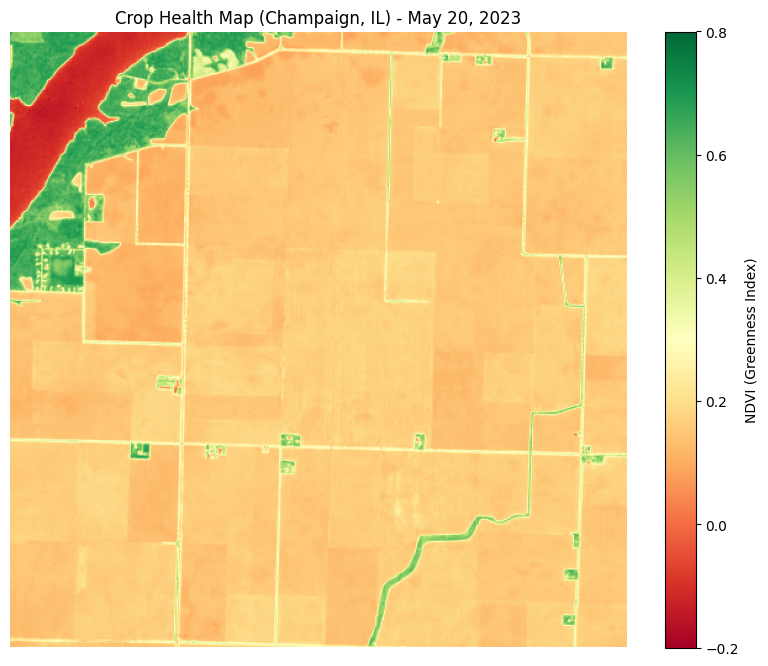

In [7]:
import matplotlib.pyplot as plt

# Create a figure
plt.figure(figsize=(10, 8))

# Display the image
# vmin=-0.2, vmax=0.8 centers the colors nicely for agriculture
im = plt.imshow(ndvi, cmap='RdYlGn', vmin=-0.2, vmax=0.8)

# Add a colorbar so we know what the colors mean
cbar = plt.colorbar(im)
cbar.set_label('NDVI (Greenness Index)')

plt.title('Crop Health Map (Champaign, IL) - May 20, 2023')
plt.axis('off') # Hide the axis numbers
plt.show()

### ndvi curve over the months

Script for reading all the files and showing the curve using ndvi data over the months

The script uses a technique called "Peak-Based Selection". 

It does not pick a random farm in May, then a different one in October.

Here is the specific logic from the code (Step 3 & 4):

- The Scout (Step 3): It looks at only one image—the "Peak Season" image (July). It scans that image, finds the single healthiest pixel, and locks onto its coordinates $(x, y)$.
- The Tracker (Step 4): It then forces the code to look at that exact same $(x, y)$ coordinate in May, August, and October.

📂 Scanning /kaggle/input/sentinel2-illinois-2023...
✅ Found 4 scenes from 2023-05-20 to 2023-10-12

📸 Generating Gallery...


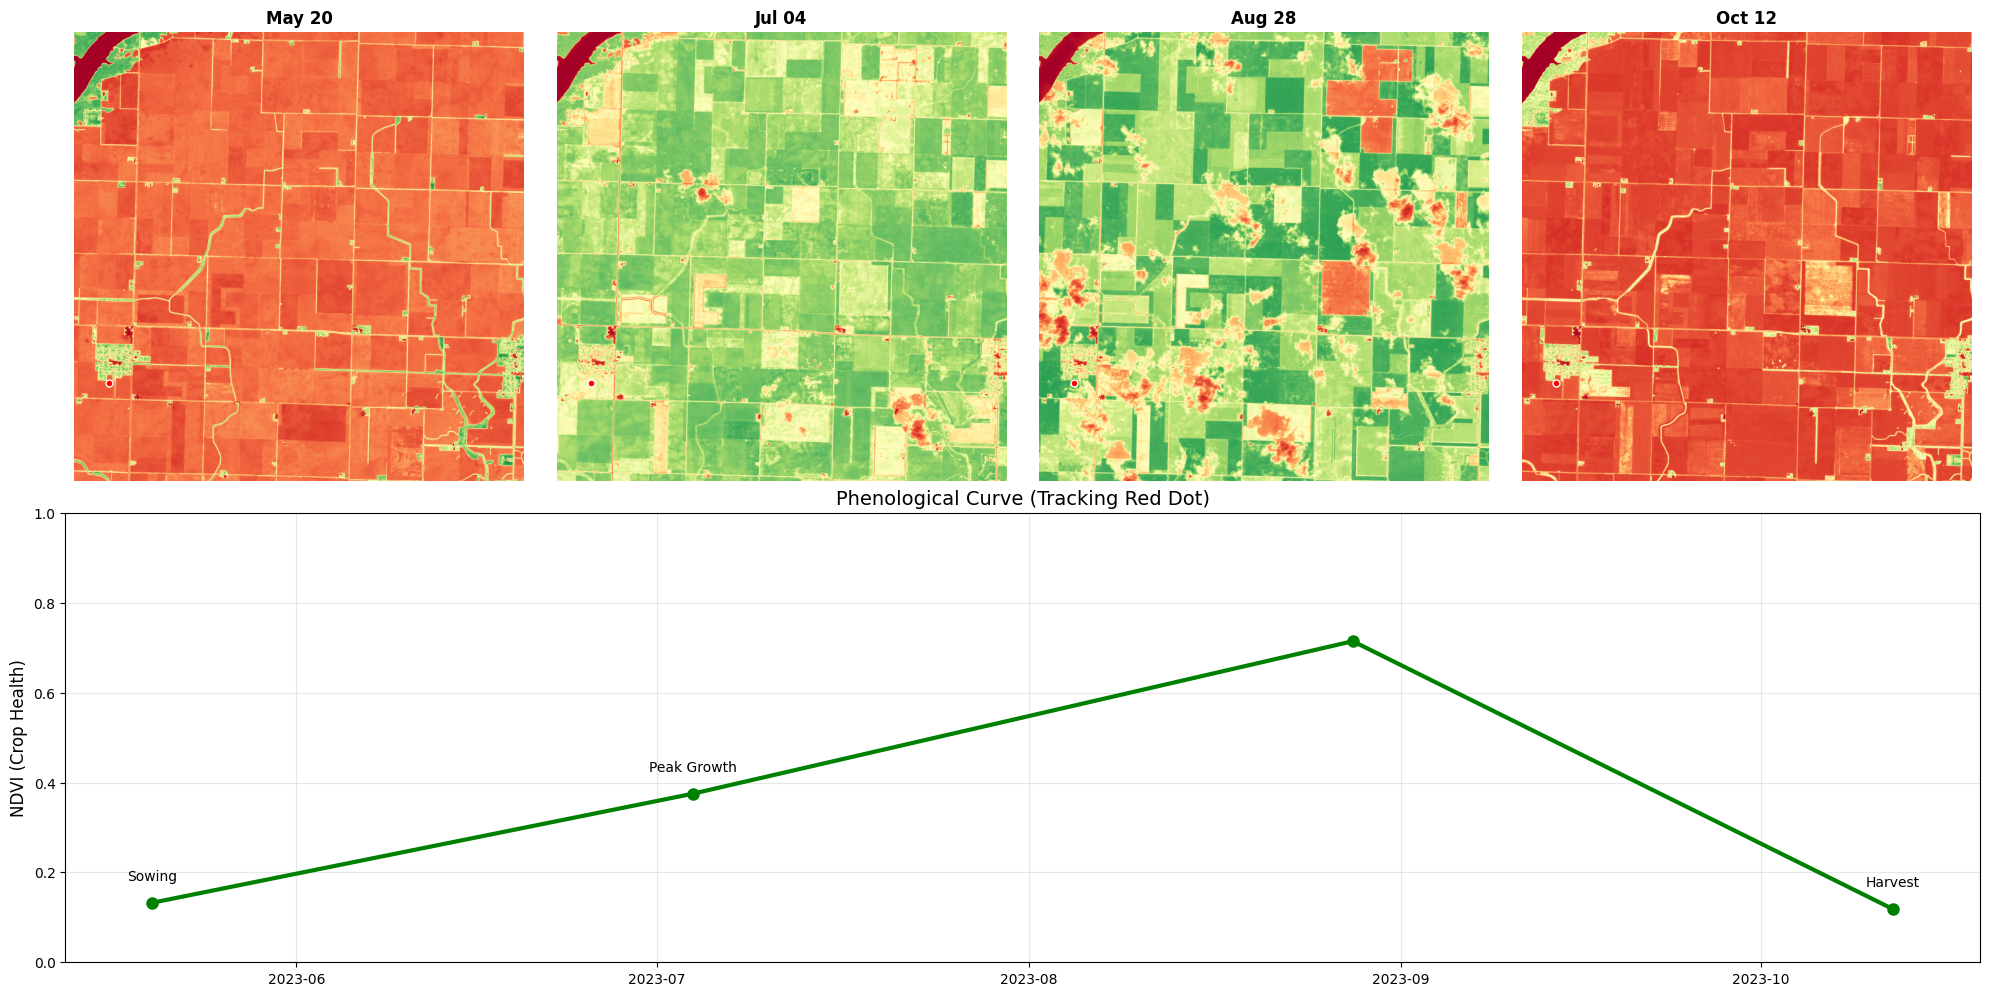

In [8]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

# ==========================================
# 1. CONFIGURATION
# ==========================================
# Change this path to point to ANY Sentinel-2 dataset folder
DATASET_ROOT = Path("/kaggle/input/sentinel2-illinois-2023") 

# How big of a patch to show? (1000px = 10km box)
VIEW_SIZE = 1000 

# ==========================================
# 2. AUTO-DISCOVERY (Generalized)
# ==========================================
def find_all_scenes(root_path):
    print(f"📂 Scanning {root_path}...")
    
    # Generalized Search: Finds B04/B08 anywhere in the folder structure
    red_files = sorted(list(root_path.rglob("*_B04_10m.jp2")))
    nir_files = sorted(list(root_path.rglob("*_B08_10m.jp2")))
    
    if len(red_files) == 0:
        print("❌ No files found! Check your dataset path.")
        return []
        
    # Pair them up
    scenes = []
    for r, n in zip(red_files, nir_files):
        # Parse Date (Standard Sentinel-2 Format: ..._20230520T...)
        try:
            date_str = r.name.split('_')[1].split('T')[0]
            date_obj = datetime.strptime(date_str, "%Y%m%d")
            scenes.append({'date': date_obj, 'red': r, 'nir': n})
        except:
            continue # Skip files with weird names
    
    # Sort by time
    scenes.sort(key=lambda x: x['date'])
    print(f"✅ Found {len(scenes)} scenes from {scenes[0]['date'].date()} to {scenes[-1]['date'].date()}")
    return scenes

# ==========================================
# 3. FARM HUNTER (Find the Greenest Pixel)
# ==========================================
def find_best_pixel(scenes):
    # Use the middle image (Peak Season) to find the farm
    peak_idx = len(scenes) // 2
    peak_scene = scenes[peak_idx]
    
    with rasterio.open(peak_scene['red']) as r, rasterio.open(peak_scene['nir']) as n:
        # Read center patch
        win = rasterio.windows.Window(5000, 5000, VIEW_SIZE, VIEW_SIZE)
        red = r.read(1, window=win).astype('float32')
        nir = n.read(1, window=win).astype('float32')
        
        # Calc NDVI
        ndvi = (nir - red) / (nir + red + 1e-8)
        ndvi[(ndvi > 0.9) | (ndvi < 0)] = 0 # Mask noise
        
        # Find max pixel
        max_idx = np.unravel_index(np.argmax(ndvi), ndvi.shape)
        best_y, best_x = max_idx
        
        # Global Coordinates (Offset + Local)
        global_x = 5000 + best_x
        global_y = 5000 + best_y
        
        return global_x, global_y, (best_x, best_y)

# ==========================================
# 4. VISUALIZATION & EXTRACTION
# ==========================================
scenes = find_all_scenes(DATASET_ROOT)

if scenes:
    # A. Locate the Farm
    gx, gy, local_coords = find_best_pixel(scenes)
    lx, ly = local_coords
    
    # B. Setup the Gallery Plot
    fig = plt.figure(figsize=(20, 10))
    grid = plt.GridSpec(2, len(scenes), height_ratios=[1, 1])
    
    timeline_dates = []
    timeline_ndvi = []
    
    print("\n📸 Generating Gallery...")
    
    # C. Loop through every date
    for i, scene in enumerate(scenes):
        with rasterio.open(scene['red']) as r, rasterio.open(scene['nir']) as n:
            # 1. Read the Patch (for the Image)
            win_patch = rasterio.windows.Window(5000, 5000, VIEW_SIZE, VIEW_SIZE)
            red_img = r.read(1, window=win_patch).astype('float32')
            nir_img = n.read(1, window=win_patch).astype('float32')
            
            # Create NDVI Map
            ndvi_map = (nir_img - red_img) / (nir_img + red_img + 1e-8)
            
            # 2. Read the Specific Pixel (for the Graph)
            # We use the EXACT coordinates found in Step 3
            win_px = rasterio.windows.Window(gx, gy, 1, 1)
            px_r = r.read(1, window=win_px)[0,0]
            px_n = n.read(1, window=win_px)[0,0]
            
            val = 0
            if px_r + px_n > 0:
                val = (px_n - px_r) / (px_n + px_r)
            
            timeline_dates.append(scene['date'])
            timeline_ndvi.append(val)
            
            # 3. Add Image to Gallery
            ax = fig.add_subplot(grid[0, i])
            # vmin/vmax locks the color scale so visuals are comparable
            im = ax.imshow(ndvi_map, cmap='RdYlGn', vmin=0, vmax=0.8)
            ax.set_title(scene['date'].strftime('%b %d'), fontsize=12, fontweight='bold')
            ax.axis('off')
            
            # Mark the specific pixel we are tracking
            ax.plot(lx, ly, 'ro', markersize=5, markeredgecolor='white')

    # D. Add the Curve Graph at the bottom
    ax_curve = fig.add_subplot(grid[1, :])
    ax_curve.plot(timeline_dates, timeline_ndvi, 'o-', color='green', linewidth=3, markersize=8)
    
    # Styling
    ax_curve.set_title(f"Phenological Curve (Tracking Red Dot)", fontsize=14)
    ax_curve.set_ylabel("NDVI (Crop Health)", fontsize=12)
    ax_curve.set_ylim(0, 1.0)
    ax_curve.grid(True, alpha=0.3)
    
    # Add annotations for context
    ax_curve.text(timeline_dates[0], timeline_ndvi[0]+0.05, "Sowing", ha='center', fontsize=10)
    ax_curve.text(timeline_dates[1], timeline_ndvi[1]+0.05, "Peak Growth", ha='center', fontsize=10)
    ax_curve.text(timeline_dates[-1], timeline_ndvi[-1]+0.05, "Harvest", ha='center', fontsize=10)

    plt.tight_layout()
    plt.show()

### Generation of shape model

Why?


1. **Data Compression:** Instead of feeding a machine learning model 12 raw numbers (one for each month), you feed it just **3 parameters** from the curve:
* **Amplitude ():** "How healthy was the peak?" (Distinguishes Wheat vs. Weeds).
* **Peak Day ():** "When did it flower?" (Distinguishes Winter Wheat vs. Summer Corn).
* **Width ():** "How long was the season?" (Distinguishes Soybeans vs. fast-growing veggies).


2. **Gap Filling:** Satellites miss days (clouds). A shape model lets you mathematically guess what happened on a cloudy Tuesday by following the curve.
3. **Noise Removal:** If one day has a random spike (sensor error), the smooth curve ignores it.

---

NDVI is the "Old Reliable," but it has a major flaw: **Saturation.** When corn gets *really* dense (like in your Illinois July image), NDVI gets stuck at 0.8 and stops going up, even if the crop is growing more.

Here are **3 Better Indices** you can calculate *right now* using the same bands you already have (plus a few others in the folder):

#### **1. EVI (Enhanced Vegetation Index)**

* **Why:** It doesn't get "stuck" at high density. It sees the difference between "Dense Corn" and "Very Dense Corn."
* **Formula:** Uses Blue band to correct for atmosphere.

#### **2. NDWI (Normalized Difference Water Index)**

* **Why:** It tracks **Moisture**, not greenness.
* **Formula:** Uses Green and NIR.


* **The Insight:** A crop might stay green (High NDVI) but start drying out (Low NDWI) before harvest. This tells you *exactly* when the farmer stopped watering.

#### **3. The "Red Edge" (Sentinel-2 Special)**

* **Why:** You have bands called **B5, B6, B7**. These are "Red Edge" bands. They are specifically designed to detect **Chlorophyll** content more precisely than standard Red (B4).
* **The Opportunity:** Most older papers don't use these because Landsat (the old US satellite) didn't have them. Sentinel-2 *does*. Using **B8A** and **B5** could give you a "Super-NDVI."



"Does adding the **SWIR (Moisture)** curve to the **NDVI (Greenness)** curve improve our ability to predict the harvest date?"

📂 Scanning /kaggle/input/sentinel2-illinois-2023...
🎯 Tracking Pixel (5076, 5780)...


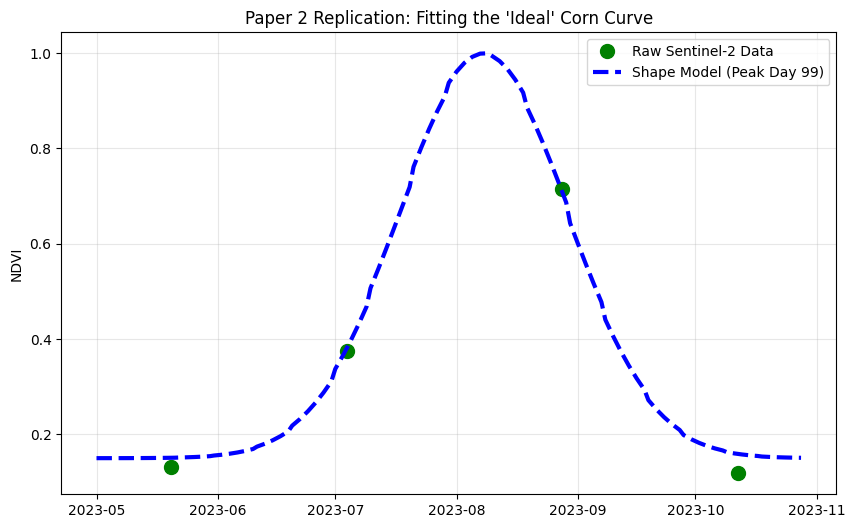

✅ Model Parameters Extracted:
   Amplitude (Health): 0.85
   Peak Day: 99 (Days since May 1)
   Duration (Width): 21 days


In [14]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime, timedelta
from scipy.optimize import curve_fit

# ==========================================
# 1. CONFIGURATION
# ==========================================
DATASET_ROOT = Path("/kaggle/input/sentinel2-illinois-2023") 

# ==========================================
# 2. AUTO-DISCOVERY & FARM HUNTER
# ==========================================
def get_clean_data(root_path):
    # A. Find Scenes
    print(f"📂 Scanning {root_path}...")
    red_files = sorted(list(root_path.rglob("*_B04_10m.jp2")))
    nir_files = sorted(list(root_path.rglob("*_B08_10m.jp2")))
    
    scenes = []
    for r, n in zip(red_files, nir_files):
        try:
            d_str = r.name.split('_')[1].split('T')[0]
            scenes.append({'date': datetime.strptime(d_str, "%Y%m%d"), 'red': r, 'nir': n})
        except: continue
    scenes.sort(key=lambda x: x['date'])
    
    # B. Find Best Pixel (Peak Season)
    peak_scene = scenes[len(scenes)//2]
    with rasterio.open(peak_scene['red']) as r, rasterio.open(peak_scene['nir']) as n:
        win = rasterio.windows.Window(5000, 5000, 1000, 1000)
        red, nir = r.read(1, window=win).astype('float32'), n.read(1, window=win).astype('float32')
        ndvi = (nir - red) / (nir + red + 1e-8)
        ndvi[(ndvi > 0.9) | (ndvi < 0)] = 0
        best_y, best_x = np.unravel_index(np.argmax(ndvi), ndvi.shape)
        gx, gy = 5000 + best_x, 5000 + best_y

    # C. Extract Timeline
    dates, ndvi_values = [], []
    print(f"🎯 Tracking Pixel ({gx}, {gy})...")
    
    for s in scenes:
        with rasterio.open(s['red']) as r, rasterio.open(s['nir']) as n:
            win = rasterio.windows.Window(gx, gy, 1, 1)
            rv, nv = r.read(1, window=win)[0,0], n.read(1, window=win)[0,0]
            if rv + nv > 0:
                dates.append(s['date'])
                ndvi_values.append((nv - rv) / (nv + rv))
                
    return dates, ndvi_values

# ==========================================
# 3. THE SHAPE MODEL (Paper 2 Logic)
# ==========================================
# Shape model: Gaussian-like phenology curve
# - a: Amplitude (Peak Health). Physically, NDVI saturates ≈0.8–0.85 for dense crops,
#      so we clamp amplitude during fitting to avoid unrealistic >0.85 fits.
# - b: Center (Peak Day)
# - c: Width (Duration)
def gaussian_model(t, a, b, c):
    # a = Amplitude (Peak Health), b = Center (Peak Day), c = Width (Duration)
    return a * np.exp(-((t - b)**2) / (2 * c**2)) + 0.15


def fit_and_plot(dates, ndvi):
    # Convert Dates to "Day of Year" (relative to May 1st)
    start_date = datetime(2023, 5, 1)
    days = np.array([(d - start_date).days for d in dates])
    
    # Fit the Curve
    # Initial Guess: Amplitude ~0.8 (within realistic NDVI range), Peak=Day 80 (July), Width=40
    p0 = [0.8, 80, 40]
    
    try:
        # Clamp amplitude to <= 0.85 to prevent fits that exceed realistic NDVI saturation values
        # Bounds: [amp_min, peak_min, width_min], [amp_max, peak_max, width_max]
        params, _ = curve_fit(
            gaussian_model,
            days,
            ndvi,
            p0=p0,
            bounds=([0, 0, 10], [0.85, 180, 100])
        )
        
        # Generate Smooth Line
        t_smooth = np.linspace(0, 180, 100)
        ndvi_smooth = gaussian_model(t_smooth, *params)
        date_smooth = [start_date + timedelta(days=int(d)) for d in t_smooth]
        
        # PLOT
        plt.figure(figsize=(10, 6))
        plt.plot(dates, ndvi, 'go', markersize=10, label="Raw Sentinel-2 Data")
        plt.plot(date_smooth, ndvi_smooth, 'b--', linewidth=3, label=f"Shape Model (Peak Day {int(params[1])})")
        
        plt.title(f"Paper 2 Replication: Fitting the 'Ideal' Corn Curve")
        plt.ylabel("NDVI")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()
        
        print(f"✅ Model Parameters Extracted:")
        print(f"   Amplitude (Health): {params[0]:.2f}")
        print(f"   Peak Day: {int(params[1])} (Days since May 1)")
        print(f"   Duration (Width): {int(params[2])} days")
        
    except Exception as e:
        print(f"❌ Curve fitting failed: {e}")

# ==========================================
# 4. EXECUTION
# ==========================================
# Run the pipeline
dates, ndvi = get_clean_data(DATASET_ROOT)
if dates:
    fit_and_plot(dates, ndvi)

Standard Corn in Illinois peaks in Mid-July.

You have likely found a Soybean field (which peaks later) or a Late-planted Corn field.

In [15]:
import os
from pathlib import Path

# ==========================================
# CONFIGURATION
# ==========================================
DATASET_ROOT = Path("/kaggle/input/sentinel2-illinois-2023")

# ==========================================
# BAND INVENTORY SCANNER
# ==========================================
def scan_bands(root_path):
    print(f"📡 Scanning Dataset Inventory at: {root_path}\n")
    
    # Find all .SAFE folders (each one is a date)
    safe_folders = sorted(list(root_path.rglob("*.SAFE")))
    
    if not safe_folders:
        print("❌ No .SAFE folders found. Check your path.")
        return

    for safe in safe_folders:
        # Extract Date from folder name
        try:
            date_str = safe.name.split('_')[1].split('T')[0]
        except:
            date_str = "Unknown Date"
            
        print(f"📅 Date: {date_str}")
        print(f"   📂 Path: {safe.name}")
        
        # Look specifically inside IMG_DATA to see what bands we downloaded
        # They are usually split into R10m, R20m, R60m folders
        img_data_path = list(safe.rglob("IMG_DATA"))
        
        if not img_data_path:
            print("   ⚠️ No IMG_DATA folder found inside this SAFE archive.")
            continue
            
        # Go deeper into resolutions
        found_bands = []
        for resolution_folder in img_data_path[0].iterdir():
            if resolution_folder.is_dir():
                # List .jp2 files in this resolution
                bands = sorted(list(resolution_folder.glob("*.jp2")))
                band_names = [b.name.split('_')[-2] for b in bands] # Extracts 'B02', 'B8A', etc.
                
                if band_names:
                    print(f"      Resolution {resolution_folder.name}: {', '.join(band_names)}")
                    found_bands.extend(band_names)
        
        if not found_bands:
            print("      ❌ No .jp2 band files found.")
        print("-" * 50)

# ==========================================
# EXECUTION
# ==========================================
scan_bands(DATASET_ROOT)

📡 Scanning Dataset Inventory at: /kaggle/input/sentinel2-illinois-2023

📅 Date: MSIL2A
   📂 Path: S2A_MSIL2A_20230520T163841_N0510_R126_T16TCK_20240904T043944.SAFE
      Resolution R10m: AOT, B02, B03, B04, B08, TCI, WVP
      Resolution R20m: AOT, B01, B02, B03, B04, B05, B06, B07, B11, B12, B8A, SCL, TCI, WVP
      Resolution R60m: AOT, B01, B02, B03, B04, B05, B06, B07, B09, B11, B12, B8A, SCL, TCI, WVP
--------------------------------------------------
📅 Date: MSIL2A
   📂 Path: S2A_MSIL2A_20230520T163841_N0510_R126_T16TCK_20240904T043944.SAFE
      Resolution R10m: AOT, B02, B03, B04, B08, TCI, WVP
      Resolution R20m: AOT, B01, B02, B03, B04, B05, B06, B07, B11, B12, B8A, SCL, TCI, WVP
      Resolution R60m: AOT, B01, B02, B03, B04, B05, B06, B07, B09, B11, B12, B8A, SCL, TCI, WVP
--------------------------------------------------
📅 Date: MSIL2A
   📂 Path: S2A_MSIL2A_20230828T163841_N0510_R126_T16TCK_20241027T200604.SAFE
      Resolution R10m: AOT, B02, B03, B04, B08, TCI, WVP
 

### **I. The Visible Spectrum (The "Photosynthesis Engine")**

Plants absorb visible light to power photosynthesis. If a plant is "eating" light, it won't reflect it back to the satellite.

* **Band 2: `B02` — Blue (490 nm)**
  * **Biology:** Chlorophyll and carotenoids absorb blue light heavily.
  * **Use:** Mostly used for atmospheric correction / aerosol removal (e.g., in EVI).

* **Band 3: `B03` — Green (560 nm)**
  * **Biology:** Plants reflect green light; correlates with chlorophyll content.
  * **Use:** Vegetation shading and visual interpretation.

* **Band 4: `B04` — Red (665 nm)**
  * **Biology:** Heavily absorbed by chlorophyll — low reflectance indicates healthy vegetation.
  * **Use:** Core input to NDVI and many other indices.

---

### **II. The "Invisible" Spectrum (Structure & Stress)**

* **Bands `B05`, `B06`, `B07` — Red Edge (705, 740, 783 nm)**
  * **Biology:** Sensitive to chlorophyll structure; shifts with stress.
  * **Use:** `NDRE` and early stress detection.

* **Bands `B08` / `B8A` — Near-Infrared (842 / 865 nm)**
  * **Biology:** Indicates leaf/canopy structure and biomass.
  * **Use:** `NDVI`, `EVI`, and structural analyses.

---

### **III. The Moisture Meters (Water Content)**

* **Bands `B11`, `B12` — SWIR (1610 / 2190 nm)**
  * **Biology:** Water strongly absorbs SWIR; brighter SWIR ⇒ drier vegetation/soil.
  * **Use:** `NDWI` (moisture / senescence tracking).

---

### **IV. The "Combination Metrics" (Vegetation Indices)**

Below are the formulas, recommended bands, and short notes so you can compute them directly from the Sentinel-2 `.jp2` files.

1. **NDVI (Normalized Difference Vegetation Index)**
   - Formula: `NDVI = (NIR - Red) / (NIR + Red)`  
   - Bands: `NIR = B08` (or `B8A`), `Red = B04`  
   - Range: [-1, 1]. Sensitive to green biomass but saturates at high LAI (~0.8–0.9).

2. **EVI (Enhanced Vegetation Index)**
   - Formula: `EVI = 2.5 * (NIR - Red) / (NIR + 6*Red - 7.5*Blue + 1)`  
   - Bands: `NIR = B08`, `Red = B04`, `Blue = B02`  
   - Notes: Corrects for atmosphere/soil; less saturation in dense canopies.

3. **NDWI (Gao's NDWI — moisture-sensitive)**
   - Formula: `NDWI = (NIR - SWIR) / (NIR + SWIR)`  
   - Bands: `NIR = B08`, `SWIR = B11` (or `B12`)  
   - Use: Tracks leaf/soil moisture and senescence.

4. **NDRE (Normalized Difference Red Edge)**
   - Formula: `NDRE = (NIR - RedEdge) / (NIR + RedEdge)`  
   - Bands: `NIR = B08` (or `B8A`), `RedEdge = B05` (or `B06`/`B07`)  
   - Use: More sensitive to chlorophyll / nitrogen than NDVI at high biomass.

5. **SAVI (Soil-Adjusted Vegetation Index)**
   - Formula: `SAVI = ((NIR - Red) / (NIR + Red + L)) * (1 + L)`  
   - Typical `L = 0.5` for intermediate vegetation cover.  
   - Use: Better early-season (low vegetation fraction) index than NDVI.

---

Quick reference table (bands shown as Sentinel-2 band codes):

| Index | Formula (compact) | Bands used | Best for |
|---|---:|---|---|
| NDVI | `(B08 - B04)/(B08 + B04)` | `B08`, `B04` | Baseline vegetation/biomass |
| EVI | `2.5*(B08-B04)/(B08+6*B04-7.5*B02+1)` | `B08`, `B04`, `B02` | Dense canopies / reduce saturation |
| NDWI (Gao) | `(B08 - B11)/(B08 + B11)` | `B08`, `B11` | Moisture / senescence |
| NDRE | `(B08 - B05)/(B08 + B05)` | `B08`, `B05` | Chlorophyll / N-management |
| SAVI | `((B08 - B04)/(B08 + B04 + L))*(1+L)` | `B08`, `B04` | Early season / soil influence |

> Tip: prefer `B8A` for NIR when using red-edge (`B05`) — `B8A` is spectrally closer to the red-edge bands.

If you want, I can add Python utility functions (in a new code cell) that compute all these indices from the `.jp2` files and return a time-series for the tracked pixel. Would you like those functions added? (yes/no)

📡 Scanning for Multi-Spectral Data...
✅ Found 4 complete scenes (Red/Blue/NIR/SWIR/RedEdge).
🎯 Locked on Farm at 10m Pixel: (5076, 5780)


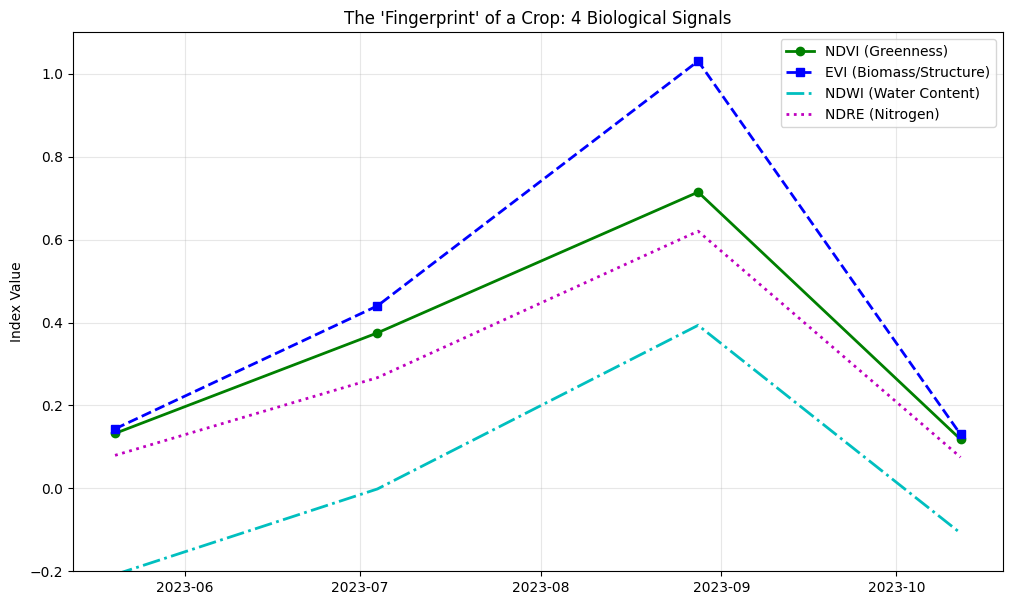

        Date      NDVI      NDWI      NDRE       EVI      SAVI
0 2023-05-20  0.132517 -0.207944  0.079618  0.143555  0.117203
1 2023-07-04  0.375000 -0.001433  0.267051  0.440154  0.308664
2 2023-08-28  0.714545  0.393296  0.620275  1.030482  0.683478
3 2023-10-12  0.118302 -0.107914  0.075099  0.130257  0.106699


In [17]:
import os
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

# ==========================================
# 1. CONFIGURATION
# ==========================================
DATASET_ROOT = Path("/kaggle/input/sentinel2-illinois-2023") 
L_SAVI = 0.5 

# ==========================================
# 2. THE ROBUST EXTRACTOR (Fixed Grouping)
# ==========================================
def extract_all_metrics(root_path):
    print(f"📡 Scanning for Multi-Spectral Data...")
    
    # Dictionary to hold files: scenes[date_string] = { 'B02': path, 'B04': path ... }
    scenes = {}
    
    # 1. SCAN and GROUP by DATE
    for jp2 in root_path.rglob("*.jp2"):
        # Identify Band
        band = None
        if "B02_10m" in jp2.name: band = 'B02'
        elif "B04_10m" in jp2.name: band = 'B04'
        elif "B08_10m" in jp2.name: band = 'B08'
        elif "B05_20m" in jp2.name: band = 'B05'
        elif "B11_20m" in jp2.name: band = 'B11'
        
        if band:
            # Extract Date from Filename (e.g., T16TCK_20230520T...)
            # This is the "Universal Key" that links R10m and R20m folders
            try:
                date_key = jp2.name.split('_')[1].split('T')[0]
            except: continue
            
            if date_key not in scenes:
                scenes[date_key] = {'date': datetime.strptime(date_key, "%Y%m%d"), 'paths': {}}
            
            scenes[date_key]['paths'][band] = jp2

    # 2. FILTER for COMPLETE SCENES
    valid_scenes = []
    for key, data in scenes.items():
        if len(data['paths']) == 5: # Must have all 5 bands
            valid_scenes.append(data)
            
    valid_scenes.sort(key=lambda x: x['date'])
    print(f"✅ Found {len(valid_scenes)} complete scenes (Red/Blue/NIR/SWIR/RedEdge).")

    if not valid_scenes:
        return pd.DataFrame()

    # --- 2b. FIND THE FARM (Using Peak Season NDVI) ---
    # Use the middle scene (July) to lock coordinates
    peak_scene = valid_scenes[len(valid_scenes)//2]
    
    with rasterio.open(peak_scene['paths']['B04']) as r, rasterio.open(peak_scene['paths']['B08']) as n:
        win = rasterio.windows.Window(5000, 5000, 1000, 1000)
        red = r.read(1, window=win).astype('float32')
        nir = n.read(1, window=win).astype('float32')
        
        ndvi = (nir - red) / (nir + red + 1e-8)
        ndvi[(ndvi > 0.9) | (ndvi < 0.2)] = 0 
        
        best_y, best_x = np.unravel_index(np.argmax(ndvi), ndvi.shape)
        gx_10m, gy_10m = 5000 + best_x, 5000 + best_y
        
    print(f"🎯 Locked on Farm at 10m Pixel: ({gx_10m}, {gy_10m})")

    # --- 2c. CALCULATE METRICS LOOP ---
    results = []
    
    for s in valid_scenes:
        try:
            # Open 10m Bands
            win_10m = rasterio.windows.Window(gx_10m, gy_10m, 1, 1)
            with rasterio.open(s['paths']['B02']) as b2, \
                 rasterio.open(s['paths']['B04']) as b4, \
                 rasterio.open(s['paths']['B08']) as b8:
                val_b2 = b2.read(1, window=win_10m)[0,0] / 10000.0
                val_b4 = b4.read(1, window=win_10m)[0,0] / 10000.0
                val_b8 = b8.read(1, window=win_10m)[0,0] / 10000.0

            # Open 20m Bands (Scale coords)
            gx_20m, gy_20m = int(gx_10m / 2), int(gy_10m / 2)
            win_20m = rasterio.windows.Window(gx_20m, gy_20m, 1, 1)
            with rasterio.open(s['paths']['B05']) as b5, \
                 rasterio.open(s['paths']['B11']) as b11:
                val_b5 = b5.read(1, window=win_20m)[0,0] / 10000.0
                val_b11 = b11.read(1, window=win_20m)[0,0] / 10000.0

            # CALCULATE INDICES
            if val_b8 + val_b4 == 0: continue

            results.append({
                'Date': s['date'],
                'NDVI': (val_b8 - val_b4) / (val_b8 + val_b4 + 1e-8),
                'NDWI': (val_b8 - val_b11) / (val_b8 + val_b11 + 1e-8),
                'NDRE': (val_b8 - val_b5) / (val_b8 + val_b5 + 1e-8),
                'EVI': 2.5 * (val_b8 - val_b4) / (val_b8 + 6 * val_b4 - 7.5 * val_b2 + 1 + 1e-8),
                'SAVI': ((val_b8 - val_b4) / (val_b8 + val_b4 + L_SAVI)) * (1 + L_SAVI)
            })
                
        except Exception as e:
            print(f"Error reading scene {s['date']}: {e}")

    return pd.DataFrame(results)

# ==========================================
# 3. VISUALIZATION
# ==========================================
df = extract_all_metrics(DATASET_ROOT)

if not df.empty:
    plt.figure(figsize=(12, 7))
    
    # Plot curves with distinct styles
    plt.plot(df['Date'], df['NDVI'], 'g-o', linewidth=2, label="NDVI (Greenness)")
    plt.plot(df['Date'], df['EVI'],  'b--s', linewidth=2, label="EVI (Biomass/Structure)")
    plt.plot(df['Date'], df['NDWI'], 'c-.', linewidth=2, label="NDWI (Water Content)")
    plt.plot(df['Date'], df['NDRE'], 'm:',  linewidth=2, label="NDRE (Nitrogen)")
    
    plt.title("The 'Fingerprint' of a Crop: 4 Biological Signals")
    plt.ylabel("Index Value")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.ylim(-0.2, 1.1)
    plt.show()
    
    print(df)